In [256]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [257]:
Data=pd.read_csv("C:/Users/rafiy/Documents/ML_BY_Rafiya/diabetes prediction.csv")

In [258]:
Data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [259]:
Data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [260]:
Data.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [261]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [262]:
Data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [263]:
Data["gender"] = Data["gender"].map({
    "Female": 0,
    "Male": 1,
    "Female":2
})

Data["gender"] = Data["gender"].fillna(0)

In [264]:
Data["smoking_history"] = Data["smoking_history"].map({
    "No Info": 1,
    "never": 2,
    "current": 3,
    "former":4,
    "ever":5,
    "not current":6
})


In [265]:
X=Data.drop('diabetes', axis=1)

In [266]:
X

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,2.0,80.0,0,1,2,25.19,6.6,140
1,2.0,54.0,0,0,1,27.32,6.6,80
2,1.0,28.0,0,0,2,27.32,5.7,158
3,2.0,36.0,0,0,3,23.45,5.0,155
4,1.0,76.0,1,1,3,20.14,4.8,155
...,...,...,...,...,...,...,...,...
99995,2.0,80.0,0,0,1,27.32,6.2,90
99996,2.0,2.0,0,0,1,17.37,6.5,100
99997,1.0,66.0,0,0,4,27.83,5.7,155
99998,2.0,24.0,0,0,2,35.42,4.0,100


In [267]:
y=Data[['diabetes']]

In [268]:
y

,diabetes
0,0
1,0
2,0
3,0
4,0
...,...
99995,0
99996,0
99997,0
99998,0


In [269]:
from sklearn.model_selection import train_test_split

In [270]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.4, random_state=42)

In [271]:
X_train

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
40507,1.0,45.0,0,0,5,30.51,4.5,80
72707,1.0,1.8,0,0,1,18.42,6.1,160
90912,1.0,26.0,0,0,3,26.66,6.5,145
28532,1.0,40.0,0,0,3,32.50,5.7,158
13006,1.0,67.0,0,0,2,38.52,5.8,240
...,...,...,...,...,...,...,...,...
6265,1.0,49.0,0,0,2,32.98,5.7,80
54886,2.0,15.0,0,0,2,28.10,5.0,159
76820,1.0,42.0,0,0,2,26.14,5.8,85
860,2.0,37.0,0,0,2,24.96,6.2,158


In [272]:
X_test

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
75721,2.0,13.0,0,0,1,20.82,5.8,126
80184,2.0,3.0,0,0,1,21.00,5.0,145
19864,1.0,63.0,0,0,4,25.32,3.5,200
76699,2.0,2.0,0,0,2,17.43,6.1,126
92991,2.0,33.0,0,0,6,40.08,6.2,200
...,...,...,...,...,...,...,...,...
84191,2.0,31.0,0,0,1,31.07,6.1,126
4373,1.0,8.0,0,0,1,27.32,6.2,85
57452,1.0,11.0,0,0,1,17.55,6.2,126
31042,2.0,56.0,0,0,2,34.13,3.5,140


In [273]:
y_train

,diabetes
40507,0
72707,0
90912,0
28532,0
13006,1
...,...
6265,0
54886,0
76820,0
860,0


In [274]:
y_test

,diabetes
75721,0
80184,0
19864,0
76699,0
92991,1
...,...
84191,0
4373,0
57452,0
31042,0


In [275]:
model = LogisticRegression()

In [276]:
model.fit(X_train, y_train)

C:\Users\rafiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\rafiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [277]:
Data.max()

gender                   2.00
age                     80.00
hypertension             1.00
heart_disease            1.00
smoking_history          6.00
bmi                     95.69
HbA1c_level              9.00
blood_glucose_level    300.00
diabetes                 1.00
dtype: float64

In [278]:
model.predict([[2.00, 76.00, 1.00, 1.00, 5.00, 85.69, 8.00, 200.00]])

C:\Users\rafiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [279]:
y_pred = model.predict(X_test)

In [280]:
print(accuracy_score(y_test, y_pred)*100)

94.265


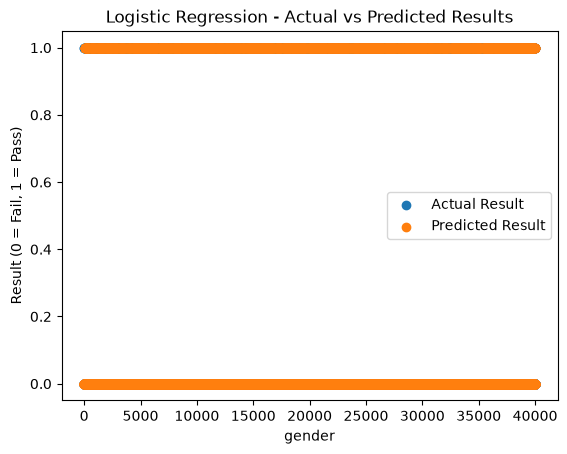

In [281]:

plt.scatter(
    range(len(y_test)),
    y_test,
    label="Actual Result"
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    label="Predicted Result"
)

plt.xlabel("gender")
plt.ylabel("Result (0 = Fail, 1 = Pass)")
plt.title("Logistic Regression - Actual vs Predicted Results")

plt.legend()
plt.show()